# Baseline FedAvg supervisionado — eixo cross-device

Notebook **somente de leitura/visualizacao**. Nao treina nada e nao escreve em `results/`.

## Fonte dos dados

Le `results/fed_cross_device_parts/*.csv` (um parcial por job), **nunca**
`results/fed_cross_device.csv`. Motivo: o driver so reescreve o CSV consolidado no
fim da grade inteira, entao durante uma execucao ele ainda contem os numeros da
grade **anterior** — leria dado velho com cara de atual. Os parciais sao
auto-datados pelo proprio conteudo.

Consequencia: o notebook roda a qualquer momento durante a grade. No comeco ele
mostra pouca coisa; isso e a verdade, nao um defeito.

## Regra de agregacao

**So entram celulas `(encoder, arm)` com as 4 seeds completas.** Uma celula pela
metade nao aparece em tabela nem em figura. Media de 2 seeds com cara de media de
4 e o modo de falha que essa regra elimina.

## Regra de selecao

O numero reportado e a acuracia de **teste na rodada escolhida pela validacao**
(`val_acc`, media sobre os alvos do spec) — nunca a ultima rodada, nunca a melhor
rodada no teste. Com `k=5` a curva do FedAvg sobe, atinge o pico cedo e degrada:
reportar a ultima rodada subnota o resultado em ate 7 pp, e escolher a melhor
rodada no teste seria selecao de modelo no conjunto de teste.

## Taxonomia dos bracos

| arm | spec | o que e |
|---|---|---|
| `in10-RW` / `in10-MS` | `device:<ds>:10` | 10 clientes, **1 por usuario real** — in-domain |
| `iid-RW` / `iid-MS` | `iid:<ds>:10` | as **mesmas janelas** em 10 fatias aleatorias — **controle de feature skew** |
| `cross5+5` | `device:RW+MS:5+5` | 10 clientes, metade de cada dataset — domain shift |
| `cross10+10` | `device:RW+MS:10+10` | 20 clientes, 10 de cada dataset |

O par `device` vs `iid` isola **feature skew** (a heterogeneidade de cada pessoa):
dataset, numero de clientes, janelas por cliente e distribuicao de classes sao
identicos; so muda se a fronteira entre clientes coincide com a fronteira entre
pessoas. Nao confundir com o `iid`/`non-iid` do trabalho cross-silo antigo
(`federated_avaliation.ipynb`), onde o eixo era **label skew**.

## 1. Setup

In [17]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
PART_DIR = PROJECT_ROOT / 'results' / 'fed_cross_device_parts'

ENCODERS = ['resnetse5', 'cnnpff', 'rnn', 'tstcc']

# Paleta categorica validada com scripts/validate_palette.js da skill dataviz
# (modo claro, 4 slots): ALL CHECKS PASS. Pior par adjacente ΔE 9.1 (protan) e
# 22.9 (visao normal). O WARN de contraste vs superficie obriga alivio por
# rotulo visivel — por isso toda figura rotula a serie e traz a tabela junto.
COLOR = dict(zip(ENCODERS, ['#2a78d6', '#eb6834', '#1baf7a', '#eda100']))
INK, INK_2 = '#0b0b0b', '#52514e'

ALIAS = {
    'device:RealWorld_thigh:10': 'in10-RW',
    'device:MotionSense:10': 'in10-MS',
    'device:RealWorld_thigh+MotionSense:10+10': 'cross10+10',
    'device:RealWorld_thigh+MotionSense:5+5': 'cross5+5',
    'iid:RealWorld_thigh:10': 'iid-RW',
    'iid:MotionSense:10': 'iid-MS',
}
ARM_ORDER = ['in10-RW', 'iid-RW', 'in10-MS', 'iid-MS', 'cross5+5', 'cross10+10']
N_SEEDS = 4
LOCAL_EPOCHS = 5  # k=5; os parciais de k=1 (R=100, resnetse5) ficam de fora

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.25, 'grid.linewidth': 0.6,
    'axes.edgecolor': '#c9c8c3', 'axes.labelcolor': INK_2,
    'text.color': INK, 'xtick.color': INK_2, 'ytick.color': INK_2,
    'font.size': 9, 'legend.frameon': False,
})


def place_labels(ax, ends, gap_frac=0.06):
    """Rotula pontas de serie empurrando-as para nao colidirem verticalmente.

    `ends` = [(x, y, texto, cor)]. Sem isto, series que terminam proximas escrevem
    uma por cima da outra, e o rotulo direto — que e o alivio exigido pelo WARN de
    contraste da paleta — deixa de cumprir sua funcao.
    """
    if not ends:
        return
    lo, hi = ax.get_ylim()
    gap = (hi - lo) * gap_frac
    ends = sorted(ends, key=lambda e: e[1])
    ys = [e[1] for e in ends]
    for i in range(1, len(ys)):
        ys[i] = max(ys[i], ys[i - 1] + gap)
    for (x, _y, txt, col), yy in zip(ends, ys):
        ax.annotate(txt, (x, yy), xytext=(5, 0), textcoords='offset points',
                    fontsize=7.5, color=col, va='center')


def series_legend(fig, mapping, order, title, ncol=None):
    """Legenda no nivel da figura — sempre presente, para >= 2 series.

    No nivel da figura, e nao de um painel: a legenda dentro do primeiro eixo
    lista so as series que aquele painel tem, o que mente quando os paineis
    diferem (o caso enquanto a grade nao fechou).
    """
    handles = [Line2D([0], [0], color=mapping[k], lw=2, label=str(k)) for k in order]
    fig.legend(handles=handles, title=title, loc='lower center',
               bbox_to_anchor=(0.5, -0.015), ncol=ncol or len(order),
               fontsize=8, title_fontsize=8)


print('parciais em', PART_DIR)

parciais em /home/miguel.barreto/fed-har/results/fed_cross_device_parts


## 2. Carga e cobertura

A tabela de cobertura vem antes de qualquer numero: ela diz o que ainda nao existe.

In [18]:
def load_parts(local_epochs=LOCAL_EPOCHS):
    # Le os parciais por job. NUNCA le results/fed_cross_device.csv (ver abertura).
    files = sorted(PART_DIR.glob('*.csv'))
    if not files:
        return pd.DataFrame()
    df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
    if 'val_acc' not in df.columns:
        df['val_acc'] = np.nan
    df = df[df.local_epochs == local_epochs].copy()
    df = df.dropna(subset=['val_acc'])
    df['arm'] = df.spec.map(ALIAS)
    return df


def coverage(df):
    # Seeds e rodadas por celula (encoder, arm); 'completa' exige as 4 seeds.
    if df.empty:
        return pd.DataFrame()
    g = df.groupby(['encoder', 'arm']).agg(
        seeds=('seed', 'nunique'), rodadas=('round', 'max'))
    g['completa'] = g.seeds >= N_SEEDS
    return g.reset_index()


def complete_only(df):
    # Filtra para as celulas completas. Celula parcial nao entra em agregado.
    if df.empty:
        return df
    cov = coverage(df)
    keep = set(zip(cov.loc[cov.completa, 'encoder'], cov.loc[cov.completa, 'arm']))
    mask = [(e, a) in keep for e, a in zip(df.encoder, df.arm)]
    return df[mask].copy()


raw = load_parts()
cov = coverage(raw)
full = complete_only(raw)

if raw.empty:
    print('Nenhum parcial com k=%d ainda. A grade provavelmente acabou de comecar:' % LOCAL_EPOCHS)
    print('cada job so escreve seu parcial quando termina as R rodadas.')
else:
    n_tot = len(ENCODERS) * len(ARM_ORDER)
    n_ok = int(cov.completa.sum())
    print('celulas (encoder x arm): %d de %d completas | %d linhas utilizaveis'
          % (n_ok, n_tot, len(full)))
    piv = cov.pivot(index='arm', columns='encoder', values='seeds')
    piv = piv.reindex(index=[a for a in ARM_ORDER if a in piv.index],
                      columns=[e for e in ENCODERS if e in piv.columns])
    display(piv.fillna(0).astype(int).style.format('{}/4').set_caption(
        'seeds prontas por celula (4/4 = entra nas analises)'))

celulas (encoder x arm): 24 de 24 completas | 19200 linhas utilizaveis


encoder,resnetse5,cnnpff,rnn,tstcc
arm,,,,
in10-RW,4/4,4/4,4/4,4/4
iid-RW,4/4,4/4,4/4,4/4
in10-MS,4/4,4/4,4/4,4/4
iid-MS,4/4,4/4,4/4,4/4
cross5+5,4/4,4/4,4/4,4/4
cross10+10,4/4,4/4,4/4,4/4


## 3. Selecao pela validacao

Para cada run `(encoder, arm, seed)`, a rodada escolhida e a de maior `val_acc`
(media sobre os alvos do spec). Essa e a mesma regra que o `--ckpt-dir` do runner
usa para gravar o `best.ckpt`, entao o numero da tabela corresponde ao checkpoint
que existe em disco.

In [19]:
def selected_rounds(df):
    # Rodada de maior val_acc por run. O teste nunca entra na escolha.
    v = df.groupby(['encoder', 'arm', 'seed', 'round'])['val_acc'].mean().reset_index()
    idx = v.groupby(['encoder', 'arm', 'seed'])['val_acc'].idxmax()
    return v.loc[idx, ['encoder', 'arm', 'seed', 'round']].rename(
        columns={'round': 'best_round'})


def at_best(df):
    # Linhas do run na rodada escolhida (uma por alvo).
    if df.empty:
        return df
    m = df.merge(selected_rounds(df), on=['encoder', 'arm', 'seed'])
    return m[m['round'] == m.best_round].copy()


best = at_best(full)

if not full.empty:
    r_max = int(full['round'].max())
    sr = selected_rounds(full)
    diag = sr.groupby('encoder')['best_round'].agg(
        media='mean', mediana='median', maxima='max',
        no_teto=lambda s: int((s == r_max).sum()), runs='size').round(1)
    print('R disponivel = %d rodadas' % r_max)
    print('\nRodada escolhida pela validacao — "no_teto" conta runs que escolheram')
    print('a ultima rodada disponivel, o sinal de que R truncou o encoder:')
    display(diag)

R disponivel = 150 rodadas

Rodada escolhida pela validacao — "no_teto" conta runs que escolheram
a ultima rodada disponivel, o sinal de que R truncou o encoder:


,media,mediana,maxima,no_teto,runs
encoder,,,,,
cnnpff,107.5,133.0,150,2,24
resnetse5,72.1,75.0,150,1,24
rnn,106.0,114.0,150,2,24
tstcc,121.0,138.5,149,0,24


## 4. Convergencia — R foi suficiente?

Curva de validacao (media das 4 seeds), uma figura por braco, uma linha por
encoder. O marcador vazado assinala a rodada mediana escolhida.

O que procurar: curva ainda **subindo** na borda direita, ou marcador colado na
borda, indicam que `R` truncou aquele encoder e o numero reportado e um piso.

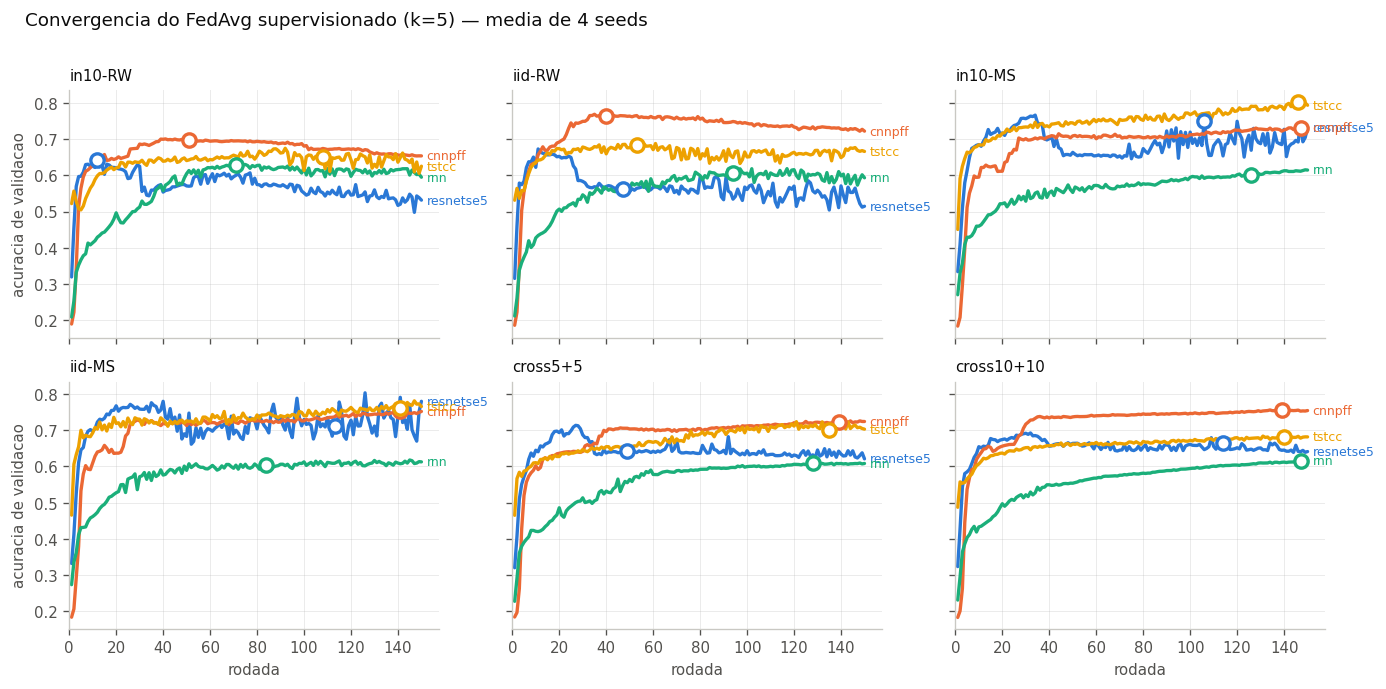

In [20]:
def plot_convergence(df):
    if df.empty:
        print('sem celula completa ainda — nada a plotar.')
        return
    arms = [a for a in ARM_ORDER if a in set(df.arm)]
    ncol = min(3, len(arms))
    nrow = int(np.ceil(len(arms) / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(4.0 * ncol, 2.9 * nrow),
                             squeeze=False, sharex=True, sharey=True)
    sr = selected_rounds(df)
    for ax, arm in zip(axes.ravel(), arms):
        sub = df[df.arm == arm]
        for enc in ENCODERS:
            s = sub[sub.encoder == enc]
            if s.empty:
                continue
            curve = s.groupby(['seed', 'round'])['val_acc'].mean().groupby('round').mean()
            ax.plot(curve.index, curve.values, lw=2, color=COLOR[enc], label=enc,
                    solid_capstyle='round')
            br = int(sr[(sr.encoder == enc) & (sr.arm == arm)].best_round.median())
            if br in curve.index:
                ax.plot([br], [curve[br]], marker='o', ms=8, mfc='white',
                        mec=COLOR[enc], mew=2, zorder=5)
            # Rotulo direto: identidade nunca depende so da cor.
            ax.annotate(enc, (curve.index[-1], curve.values[-1]), fontsize=7.5,
                        color=COLOR[enc], xytext=(3, 0), textcoords='offset points',
                        va='center')
        ax.set_title(arm, fontsize=9, color=INK, loc='left')
        ax.set_xlim(left=0)
    for ax in axes.ravel()[len(arms):]:
        ax.set_visible(False)
    for ax in axes[-1]:
        ax.set_xlabel('rodada')
    for ax in axes[:, 0]:
        ax.set_ylabel('acuracia de validacao')
    fig.suptitle('Convergencia do FedAvg supervisionado (k=5) — media de 4 seeds',
                 fontsize=11, x=0.02, ha='left', color=INK)
    fig.tight_layout(rect=[0, 0, 0.97, 0.97])
    plt.show()


plot_convergence(full)

In [21]:
# Tabela equivalente da figura acima: quanto a validacao ainda ganhou no
# ultimo quinto das rodadas. Ganho positivo = a curva nao tinha convergido.
def convergence_table(df):
    if df.empty:
        return pd.DataFrame()
    r_max = int(df['round'].max())
    lo = int(r_max * 0.8)
    rows = []
    for (enc, arm, seed), s in df.groupby(['encoder', 'arm', 'seed']):
        c = s.groupby('round')['val_acc'].mean().sort_index()
        rows.append({'encoder': enc, 'arm': arm, 'seed': seed,
                     'ganho_ultimo_quinto': max(0.0, c.loc[lo:].max() - c.loc[:lo].max()),
                     'inclinacao_final': np.polyfit(c.loc[lo:].index, c.loc[lo:].values, 1)[0]})
    t = pd.DataFrame(rows)
    out = t.groupby('encoder').agg(
        ganho_ult_quinto_pp=('ganho_ultimo_quinto', lambda s: s.mean() * 100),
        runs_ainda_subindo=('ganho_ultimo_quinto', lambda s: int((s > 0.002).sum())),
        runs=('ganho_ultimo_quinto', 'size'),
        inclinacao_pp_10r=('inclinacao_final', lambda s: s.mean() * 1000))
    return out.round(2)


ct = convergence_table(full)
if not ct.empty:
    print('Inclinacao positiva e ganho no ultimo quinto = curva ainda subindo.')
    display(ct)

Inclinacao positiva e ganho no ultimo quinto = curva ainda subindo.


,ganho_ult_quinto_pp,runs_ainda_subindo,runs,inclinacao_pp_10r
encoder,,,,
cnnpff,0.53,15,24,-0.02
resnetse5,0.19,5,24,-0.28
rnn,0.38,9,24,0.09
tstcc,0.83,17,24,0.19


## 5. Resultado principal

Acuracia de **teste** na rodada escolhida pela validacao, media +/- desvio sobre as
4 seeds, por alvo. Os bracos `cross*` tem dois alvos e aparecem duas vezes.

In [22]:
def main_table(ab):
    if ab.empty:
        return pd.DataFrame()
    t = ab.groupby(['arm', 'target', 'encoder'])['test_acc'].agg(['mean', 'std', 'size'])
    t = t.rename(columns={'mean': 'acc', 'std': 'dp', 'size': 'n'})
    return t.round(3)


mt = main_table(best)
if mt.empty:
    print('sem celula completa ainda.')
else:
    display(mt)

acc     dp  n
arm        target          encoder                   
cross10+10 MotionSense     cnnpff     0.828  0.012  4
                           resnetse5  0.877  0.040  4
                           rnn        0.667  0.039  4
                           tstcc      0.810  0.012  4
           RealWorld_thigh cnnpff     0.704  0.031  4
                           resnetse5  0.647  0.041  4
                           rnn        0.615  0.014  4
                           tstcc      0.693  0.040  4
cross5+5   MotionSense     cnnpff     0.776  0.028  4
                           resnetse5  0.801  0.043  4
                           rnn        0.602  0.033  4
                           tstcc      0.812  0.009  4
           RealWorld_thigh cnnpff     0.651  0.029  4
                           resnetse5  0.647  0.037  4
                           rnn        0.592  0.019  4
                           tstcc      0.661  0.038  4
iid-MS     MotionSense     cnnpff     0.846  0.007  4
                           resnetse5  0.905  0.024  4
                           rnn        0.723  0.040  4
                           tstcc      0.845  0.020  4
iid-RW     RealWorld_thigh cnnpff     0.753  0.018  4
                           resnetse5  0.710  0.035  4
                           rnn        0.626  0.018  4
                           tstcc      0.714  0.021  4
in10-MS    MotionSense     cnnpff     0.837  0.019  4
                           resnetse5  0.891  0.044  4
                           rnn        0.721  0.038  4
                           tstcc      0.853  0.016  4
in10-RW    RealWorld_thigh cnnpff     0.701  0.018  4
                           resnetse5  0.680  0.058  4
                           rnn        0.589  0.051  4
                           tstcc      0.711  0.027  4

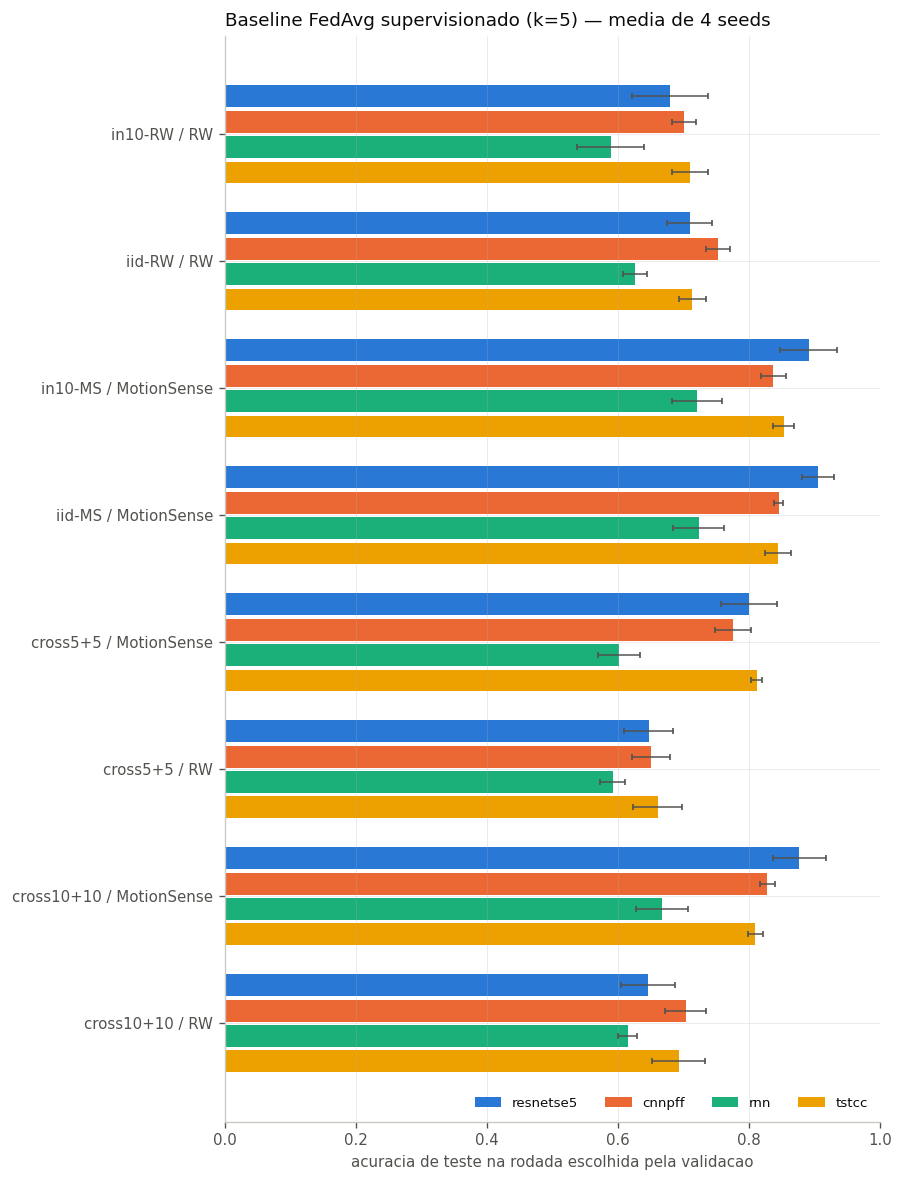

In [23]:
def plot_main(ab):
    if ab.empty:
        print('sem celula completa ainda — nada a plotar.')
        return
    g = ab.groupby(['arm', 'target', 'encoder'])['test_acc'].agg(['mean', 'std'])
    rows = [(a, t) for a in ARM_ORDER for t in sorted(set(ab[ab.arm == a].target))
            if (a, t) in {(x, y) for x, y, _ in g.index}]
    encs = [e for e in ENCODERS if e in set(ab.encoder)]
    fig, ax = plt.subplots(figsize=(7.6, 0.52 * len(rows) * max(1, len(encs)) / 2 + 1.6))
    h = 0.8 / max(1, len(encs))
    ypos = np.arange(len(rows))
    for j, enc in enumerate(encs):
        vals, errs = [], []
        for key in rows:
            k = (key[0], key[1], enc)
            vals.append(g['mean'][k] if k in g.index else np.nan)
            errs.append(g['std'][k] if k in g.index else np.nan)
        off = (j - (len(encs) - 1) / 2) * h
        ax.barh(ypos + off, vals, height=h * 0.86, color=COLOR[enc], label=enc,
                xerr=errs, error_kw=dict(ecolor=INK_2, lw=0.9, capsize=2))
    ax.set_yticks(ypos)
    ax.set_yticklabels(['%s / %s' % (a, t.replace('RealWorld_thigh', 'RW')) for a, t in rows])
    ax.invert_yaxis()
    ax.set_xlabel('acuracia de teste na rodada escolhida pela validacao')
    ax.set_xlim(0, 1)
    ax.legend(loc='lower right', ncol=len(encs), fontsize=8)
    ax.set_title('Baseline FedAvg supervisionado (k=5) — media de 4 seeds',
                 fontsize=11, loc='left', color=INK)
    fig.tight_layout()
    plt.show()


plot_main(best)

## 6. Os dois contrastes do desenho

Ambos sao **pareados por seed**: o Δ e a media das diferencas run a run, nao a
diferenca de duas medias. Quando os dois bracos nao tem as mesmas seeds, o Δ usa
a intersecao e a coluna `n` diz sobre quantos pares ele foi calculado.

- **Feature skew** = `device − iid`, mesmo alvo. Isola a heterogeneidade entre pessoas.
- **Domain shift** = `cross5+5 − in-domain de 10`, mesmo alvo e mesmo numero de clientes.

In [24]:
def paired_delta(ab, arm_a, arm_b, target):
    # Δ pareado por seed entre dois bracos, para cada encoder.
    out = []
    for enc in ENCODERS:
        s = ab[(ab.encoder == enc) & (ab.target == target)]
        x = s[s.arm == arm_a].set_index('seed')['test_acc']
        y = s[s.arm == arm_b].set_index('seed')['test_acc']
        common = x.index.intersection(y.index)
        if len(common) == 0:
            continue
        d = x[common] - y[common]
        out.append({'encoder': enc, 'alvo': target,
                    arm_a: round(x[common].mean(), 3), arm_b: round(y[common].mean(), 3),
                    'delta': round(d.mean(), 3), 'dp': round(d.std(), 3), 'n': len(common)})
    return pd.DataFrame(out)


PAIRS_SKEW = [('in10-RW', 'iid-RW', 'RealWorld_thigh'), ('in10-MS', 'iid-MS', 'MotionSense')]
PAIRS_SHIFT = [('cross5+5', 'in10-RW', 'RealWorld_thigh'), ('cross5+5', 'in10-MS', 'MotionSense')]


def delta_frame(ab, pairs):
    if ab.empty:
        return pd.DataFrame()
    fr = [paired_delta(ab, a, b, t) for a, b, t in pairs]
    fr = [f for f in fr if not f.empty]
    return pd.concat(fr, ignore_index=True) if fr else pd.DataFrame()


skew = delta_frame(best, PAIRS_SKEW)
shift = delta_frame(best, PAIRS_SHIFT)
if skew.empty and shift.empty:
    print('nenhum par de bracos completo ainda.')
else:
    print('Δ FEATURE SKEW (device - iid): negativo = particionar por usuario custa.')
    display(skew)
    print('\nΔ DOMAIN SHIFT (cross5+5 - in-domain): negativo = trocar metade dos clientes custa.')
    display(shift)

Δ FEATURE SKEW (device - iid): negativo = particionar por usuario custa.


,encoder,alvo,in10-RW,iid-RW,delta,dp,n,in10-MS,iid-MS
0,resnetse5,RealWorld_thigh,0.680,0.710,-0.030,0.029,4,NaN,NaN
1,cnnpff,RealWorld_thigh,0.701,0.753,-0.052,0.008,4,NaN,NaN
2,rnn,RealWorld_thigh,0.589,0.626,-0.037,0.036,4,NaN,NaN
3,tstcc,RealWorld_thigh,0.711,0.714,-0.003,0.032,4,NaN,NaN
4,resnetse5,MotionSense,NaN,NaN,-0.014,0.036,4,0.891,0.905
5,cnnpff,MotionSense,NaN,NaN,-0.008,0.013,4,0.837,0.846
6,rnn,MotionSense,NaN,NaN,-0.002,0.059,4,0.721,0.723
7,tstcc,MotionSense,NaN,NaN,0.009,0.010,4,0.853,0.845



Δ DOMAIN SHIFT (cross5+5 - in-domain): negativo = trocar metade dos clientes custa.


,encoder,alvo,cross5+5,in10-RW,delta,dp,n,in10-MS
0,resnetse5,RealWorld_thigh,0.647,0.680,-0.032,0.054,4,NaN
1,cnnpff,RealWorld_thigh,0.651,0.701,-0.051,0.023,4,NaN
2,rnn,RealWorld_thigh,0.592,0.589,0.003,0.040,4,NaN
3,tstcc,RealWorld_thigh,0.661,0.711,-0.050,0.021,4,NaN
4,resnetse5,MotionSense,0.801,NaN,-0.091,0.031,4,0.891
5,cnnpff,MotionSense,0.776,NaN,-0.061,0.019,4,0.837
6,rnn,MotionSense,0.602,NaN,-0.119,0.033,4,0.721
7,tstcc,MotionSense,0.812,NaN,-0.041,0.020,4,0.853


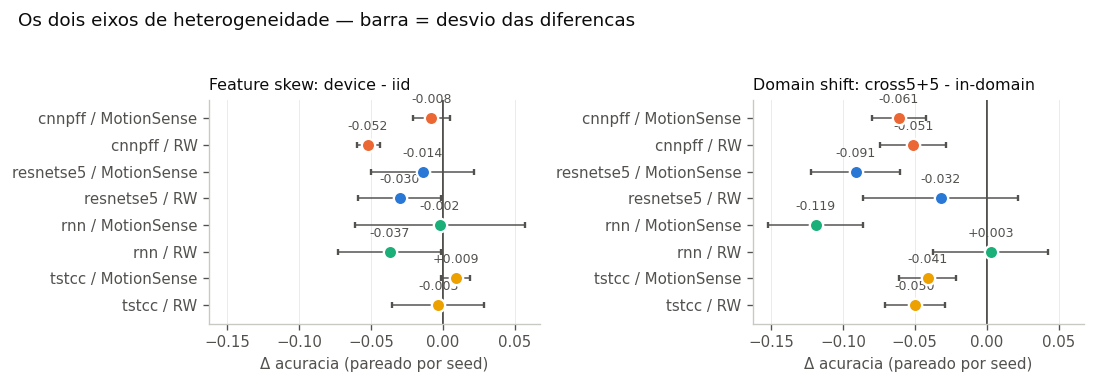

In [25]:
def plot_deltas(frames_labels):
    frames_labels = [(f, lab) for f, lab in frames_labels if not f.empty]
    if not frames_labels:
        print('sem Δ calculavel ainda — nada a plotar.')
        return
    fig, axes = plt.subplots(1, len(frames_labels), figsize=(4.6 * len(frames_labels), 3.2),
                             squeeze=False, sharex=True)
    for ax, (f, lab) in zip(axes[0], frames_labels):
        f = f.copy()
        f['row'] = f.encoder + ' / ' + f.alvo.str.replace('RealWorld_thigh', 'RW', regex=False)
        f = f.sort_values('row', ascending=False).reset_index(drop=True)
        y = np.arange(len(f))
        ax.axvline(0, color=INK_2, lw=1.2, zorder=1)
        for i, r in f.iterrows():
            ax.errorbar(r['delta'], y[i], xerr=r['dp'], fmt='o', ms=8,
                        color=COLOR[r['encoder']], ecolor=INK_2, elinewidth=0.9,
                        capsize=2, mec='white', mew=1.4, zorder=3)
            ax.annotate('%+.3f' % r['delta'], (r['delta'], y[i]), fontsize=7.5,
                        color=INK_2, xytext=(0, 9), textcoords='offset points', ha='center')
        ax.set_yticks(y)
        ax.set_yticklabels(f['row'])
        ax.set_ylim(-0.7, len(f) - 0.3)
        ax.set_title(lab, fontsize=9.5, loc='left', color=INK)
        ax.set_xlabel('Δ acuracia (pareado por seed)')
        ax.grid(axis='y', alpha=0)
    fig.suptitle('Os dois eixos de heterogeneidade — barra = desvio das diferencas',
                 fontsize=11, x=0.02, ha='left', color=INK)
    fig.tight_layout(rect=[0, 0, 1, 0.94])
    plt.show()


plot_deltas([(skew, 'Feature skew: device - iid'),
             (shift, 'Domain shift: cross5+5 - in-domain')])

## 7. Custo de comunicacao

`uplink_mb` e por rodada (soma sobre os clientes). Duas leituras, e elas respondem
perguntas diferentes:

1. **Custo fixo por rodada** — funcao do tamanho do modelo e do numero de
   clientes. E o preco de entrada de cada encoder no eixo federado, independente
   de quanto ele acerta.
2. **Custo acumulado ate a rodada escolhida** — o que o braco efetivamente gastou
   para chegar ao numero reportado da Secao 5.

E o eixo em que o Fed-SSL tera de ser comparado tambem, e ele e **duro com o
Fed-SSL**: aquele braco gasta rodadas de pre-treino que este baseline nao gasta.
Comparar "Fed-SSL apos R_pre + r rodadas" contra "FedAvg apos r rodadas" seria dar
comunicacao de graca ao Fed-SSL. Por isso a comparacao final tera **duas leituras**:
casada por rodada de fine-tuning, e casada por comunicacao total.

> **Sobre o eixo x logaritmico da segunda figura.** O `tstcc` trafega 127 MB por
> rodada contra 5,2–6,5 MB dos outros tres — 20 a 24x mais. Num eixo linear as
> tres fronteiras baratas colapsam contra o zero e ficam ilegiveis. O log e sobre
> um eixo continuo (posicao), nao sobre comprimento de barra, e a distancia
> horizontal entre as curvas passa a ler-se diretamente como "quantas vezes mais
> bytes" — que e exatamente a pergunta.

In [26]:
def comm_cost(ab):
    if ab.empty:
        return pd.DataFrame()
    one = ab.drop_duplicates(subset=['encoder', 'arm', 'seed'])
    one = one.assign(total_uplink_gb=one.uplink_mb * one.best_round / 1024)
    t = one.groupby(['encoder', 'arm']).agg(
        rodada=('best_round', 'mean'),
        mb_por_rodada=('uplink_mb', 'first'),
        uplink_ate_selecao_gb=('total_uplink_gb', 'mean'))
    return t.round(2)


cc = comm_cost(best)
if cc.empty:
    print('sem celula completa ainda.')
else:
    display(cc)

rodada  mb_por_rodada  uplink_ate_selecao_gb
encoder   arm                                                     
cnnpff    cross10+10  140.25          11.13                   1.52
          cross5+5    117.00           5.56                   0.64
          iid-MS      136.50           5.56                   0.74
          iid-RW       47.25           5.56                   0.26
          in10-MS     142.75           5.56                   0.78
          in10-RW      61.25           5.56                   0.33
resnetse5 cross10+10  102.00          10.46                   1.04
          cross5+5     54.25           5.23                   0.28
          iid-MS      104.50           5.23                   0.53
          iid-RW       58.25           5.23                   0.30
          in10-MS      98.75           5.23                   0.50
          in10-RW      14.75           5.23                   0.08
rnn       cross10+10  139.50          13.04                   1.78
          cross5+5    115.75           6.52                   0.74
          iid-MS       89.50           6.52                   0.57
          iid-RW       96.00           6.52                   0.61
          in10-MS     110.50           6.52                   0.70
          in10-RW      84.50           6.52                   0.54
tstcc     cross10+10  140.00         254.18                  34.75
          cross5+5    132.75         127.09                  16.48
          iid-MS      141.25         127.09                  17.53
          iid-RW       71.75         127.09                   8.91
          in10-MS     144.75         127.09                  17.97
          in10-RW      95.25         127.09                  11.82

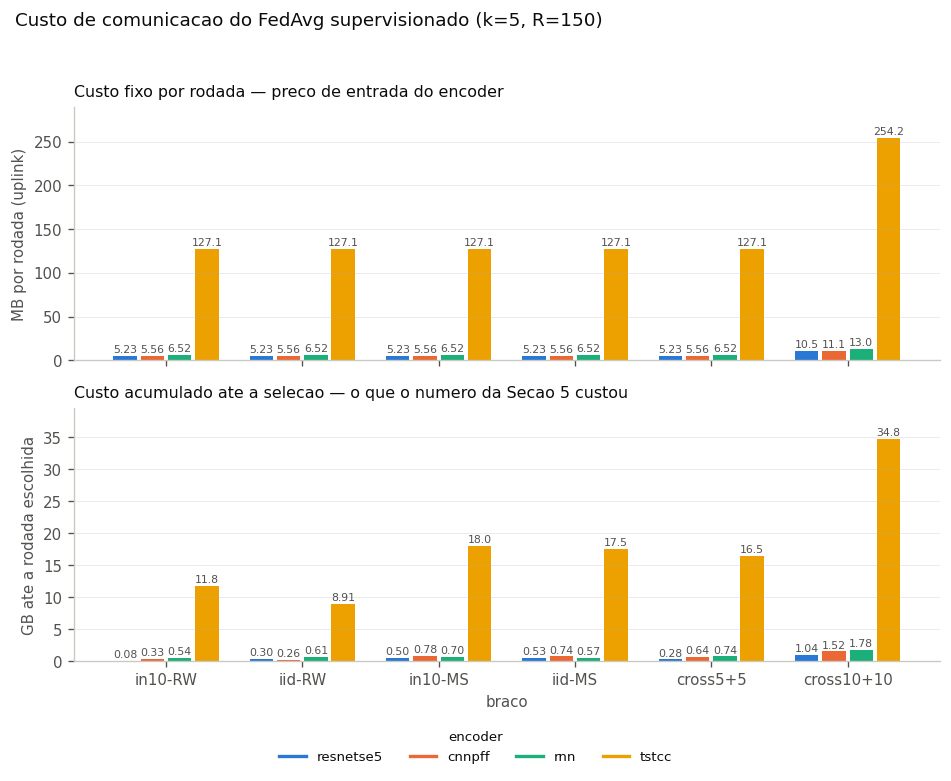

In [27]:
def plot_comm_bars(ab):
    # Leitura 1: custo fixo por rodada, e custo acumulado ate a selecao.
    # Dois paineis porque sao duas grandezas diferentes — nunca dois eixos y na
    # mesma figura. Escala LINEAR: o comprimento da barra tem de ser proporcional
    # ao valor, e a ordem de grandeza que separa o tstcc dos outros E o achado.
    if ab.empty:
        print('sem celula completa ainda — nada a plotar.')
        return
    cc = comm_cost(ab).reset_index()
    arms = [a for a in ARM_ORDER if a in set(cc.arm)]
    encs = [e for e in ENCODERS if e in set(cc.encoder)]
    if not arms or not encs:
        return
    fig, axes = plt.subplots(2, 1, figsize=(8.0, 6.4), sharex=True)
    specs = [('mb_por_rodada', 'MB por rodada (uplink)',
              'Custo fixo por rodada — preco de entrada do encoder'),
             ('uplink_ate_selecao_gb', 'GB ate a rodada escolhida',
              'Custo acumulado ate a selecao — o que o numero da Secao 5 custou')]
    x = np.arange(len(arms))
    w = 0.8 / len(encs)
    for ax, (col, ylab, title) in zip(axes, specs):
        g = cc.pivot_table(index='arm', columns='encoder', values=col)
        g = g.reindex(index=arms, columns=encs)
        for j, enc in enumerate(encs):
            off = (j - (len(encs) - 1) / 2) * w
            # width * 0.86 deixa o vao de superficie entre barras adjacentes.
            bars = ax.bar(x + off, g[enc].values, width=w * 0.86,
                          color=COLOR[enc], label=enc)
            for b, v in zip(bars, g[enc].values):
                if np.isfinite(v):
                    ax.annotate(('%.1f' if v >= 10 else '%.2f') % v,
                                (b.get_x() + b.get_width() / 2, v), xytext=(0, 2),
                                textcoords='offset points', ha='center',
                                fontsize=6.5, color=INK_2)
        ax.set_ylabel(ylab)
        ax.margins(y=0.14)
        ax.grid(axis='x', alpha=0)
        ax.set_title(title, fontsize=9.5, loc='left', color=INK)
    axes[-1].set_xticks(x)
    axes[-1].set_xticklabels(arms)
    axes[-1].set_xlabel('braco')
    fig.suptitle('Custo de comunicacao do FedAvg supervisionado (k=5, R=150)',
                 fontsize=11, x=0.02, ha='left', color=INK)
    series_legend(fig, COLOR, encs, 'encoder')
    fig.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.show()


plot_comm_bars(best)

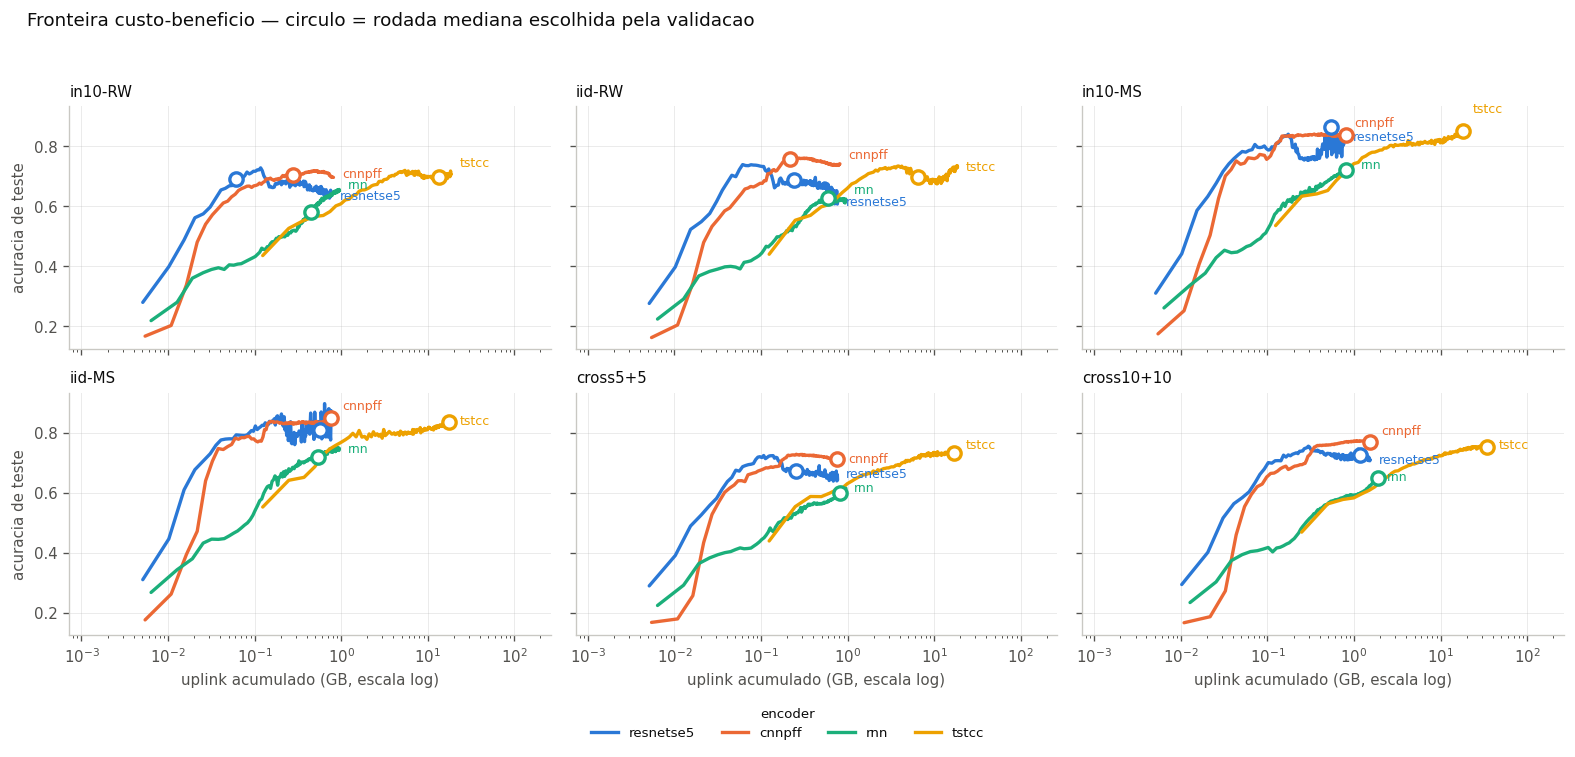

In [28]:
def plot_comm_frontier(df, ab):
    # Leitura 2: fronteira custo-beneficio. Trajetoria ao longo das rodadas —
    # x = uplink acumulado (log), y = acuracia de teste. Um painel por braco, uma
    # linha por encoder (mesma cor do resto do notebook: cor segue a entidade).
    # E linha, nao scatter: a serie percorre as rodadas, entao a lista de pares de
    # cor relevante e a de vizinhos, onde a paleta valida.
    # Log no x porque o tstcc gasta ~20x mais por rodada; ver a nota da Secao 7.
    if df.empty or ab.empty:
        print('sem celula completa ainda — nada a plotar.')
        return
    arms = [a for a in ARM_ORDER if a in set(df.arm)]
    ncol = min(3, len(arms))
    nrow = int(np.ceil(len(arms) / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(4.4 * ncol, 3.1 * nrow),
                             squeeze=False, sharex=True, sharey=True)
    sel = ab.drop_duplicates(subset=['encoder', 'arm', 'seed'])
    for ax, arm in zip(axes.ravel(), arms):
        sub = df[df.arm == arm]
        ends = []
        for enc in ENCODERS:
            s = sub[sub.encoder == enc]
            if s.empty:
                continue
            curve = s.groupby('round').agg(acc=('test_acc', 'mean'),
                                           mb=('uplink_mb', 'first'))
            gb = curve.mb * curve.index / 1024
            ax.plot(gb, curve.acc, lw=2, color=COLOR[enc], label=enc,
                    solid_capstyle='round')
            # Marcador vazado = rodada mediana escolhida pela validacao.
            br = sel[(sel.encoder == enc) & (sel.arm == arm)]
            if not br.empty:
                r = int(br.best_round.median())
                if r in curve.index:
                    ax.plot([curve.mb.iloc[0] * r / 1024], [curve.acc[r]],
                            marker='o', ms=8, mfc='white', mec=COLOR[enc],
                            mew=2, zorder=5)
            ends.append((gb.iloc[-1], curve.acc.iloc[-1], enc, COLOR[enc]))
        ax.set_xscale('log')
        ax.set_title(arm, fontsize=9, color=INK, loc='left')
        ax.margins(x=0.22)
        place_labels(ax, ends)
    for ax in axes.ravel()[len(arms):]:
        ax.set_visible(False)
    for ax in axes[-1]:
        ax.set_xlabel('uplink acumulado (GB, escala log)')
    for ax in axes[:, 0]:
        ax.set_ylabel('acuracia de teste')
    fig.suptitle('Fronteira custo-beneficio — circulo = rodada mediana escolhida pela validacao',
                 fontsize=11, x=0.02, ha='left', color=INK)
    series_legend(fig, COLOR, [e for e in ENCODERS if e in set(df.encoder)], 'encoder')
    fig.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.show()


plot_comm_frontier(full, best)

## 8. Leitura

Preencher conforme a grade fecha. Perguntas que este notebook responde:

1. **`R` bastou?** Secao 4 — inclinacao final positiva ou runs `no_teto` > 0
   significam que o numero daquele encoder e um piso, nao um teto.
2. **Feature skew importa?** Secao 6, painel esquerdo — se o Δ troca de sinal
   entre encoders e o desvio cobre o zero, o controle deu nulo e a particao por
   usuario dentro de um mesmo dataset nao e um regime non-IID dificil.
3. **Quanto custa o domain shift?** Secao 6, painel direito — e o eixo que o
   Fed-SSL precisa atacar.
4. **A hipotese-pilar se sustenta?** **Secao 9** — leva o item 3 a serio como
   teste, separando o efeito do dominio do confundidor de volume de dado, e
   confrontando-o com uma medida independente de distancia entre dominios.

### O que este notebook nao responde

Nao ha comparacao com Fed-SSL aqui: este e o contrafactual, medido sozinho. A
comparacao entra em notebook proprio quando o braco Fed-SSL existir.

---

## 9. À prova: federações supervisionadas são prejudicadas sob domain shift?

Esta é a hipótese que serve de **pilar** ao trabalho — se ela não valer aqui, não há
problema para o Fed-SSL atacar. Ela é bem estabelecida na literatura; o objetivo desta
seção não é descobri-la, é **medi-la nesta base, com estes encoders e este protocolo**,
para que o resto se apoie em número próprio e não em citação.

### 9.1 Dois contrastes, duas forças de afirmação

| braço | clientes do alvo | clientes estrangeiros | janelas do alvo | total |
|---|---|---|---|---|
| `in10-RW` | 10 | 0 | 1.920 | 1.920 |
| `cross5+5` | 5 | 5 | 960 | 1.920 |
| `cross10+10` | 10 | 10 | 1.920 | 3.840 |

**`cross5+5 − in10` testa se os domínios são intercambiáveis.** Sob a hipótese nula —
não há domain shift —, uma janela do MotionSense vale exatamente o que vale uma do
RealWorld, e trocar metade dos clientes não muda nada: mesmo número de clientes, mesmo
orçamento por cliente, mesmo total. **Qualquer queda já refuta a nula.** Não é correto
tratar "metade do dado próprio saiu" como confundidor: *dado próprio valer mais que
dado estrangeiro* **é** a definição de domain shift, não uma explicação alternativa
a ele.

**`cross10+10 − in10` testa uma afirmação mais forte: transferência negativa.** Aqui
o dado do alvo está **intacto** e ainda entram 1.920 janelas rotuladas por cima. Se o
dado estrangeiro fosse apenas *menos valioso*, acrescentá-lo ainda ajudaria — algum
ganho é melhor que nenhum. Uma queda aqui significa que ele é **ativamente nocivo**:
rótulos a mais que pioraram o modelo.

Os dois medem o mesmo fenômeno em intensidades diferentes: espera-se o primeiro
negativo com folga, e o segundo, se negativo, por margem menor. Ambos pareados por
seed — o Δ é a média das diferenças run a run.

> Mesmo enquadramento de `cross_device_fewshot_avaliation.ipynb` §6.1, que mede os
> dois contrastes ao longo da ladder de rótulos. Lá aparece um resultado que esta
> seção, presa ao degrau `full`, não consegue ver.


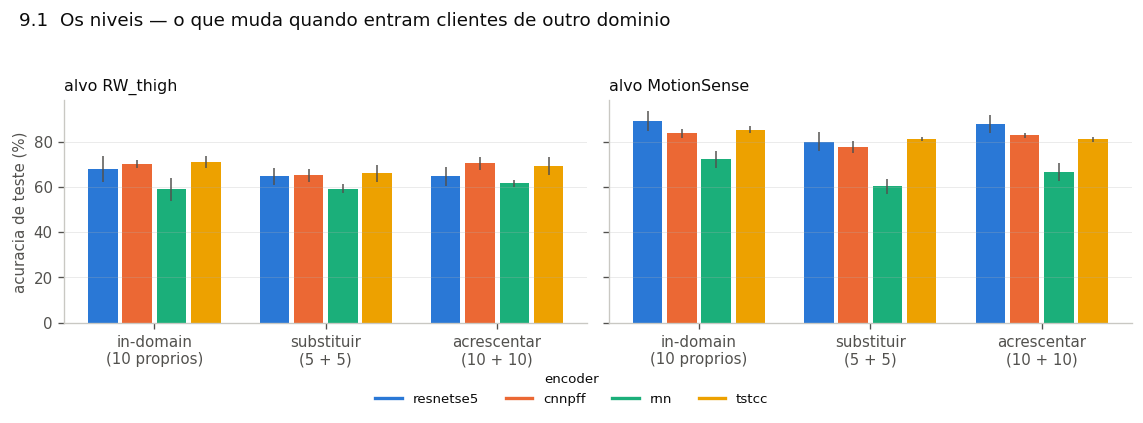

Acuracia media por braco e alvo (%) — a tabela que a figura resume:


arm,in10-RW,in10-MS,cross5+5,cross10+10
target,,,,
MotionSense,NaN,82.6,74.8,79.6
RealWorld_thigh,67.0,NaN,63.8,66.5


In [29]:
IN_ARM = {'RealWorld_thigh': 'in10-RW', 'MotionSense': 'in10-MS'}
TGT = ['RealWorld_thigh', 'MotionSense']
CURTO = {'RealWorld_thigh': 'RW_thigh', 'MotionSense': 'MotionSense'}
CONTRASTES = {'substituir': 'cross5+5', 'acrescentar': 'cross10+10'}


def tidy_contraste(ab):
    """Δ pareado por seed, em pp, para os dois contrastes x dois alvos."""
    fr = []
    for rot, arm in CONTRASTES.items():
        f = delta_frame(ab, [(arm, IN_ARM[t], t) for t in TGT])
        if f.empty:
            continue
        fr.append(f[['encoder', 'alvo', 'delta', 'dp', 'n']].assign(contraste=rot))
    if not fr:
        return pd.DataFrame()
    out = pd.concat(fr, ignore_index=True)
    out[['delta', 'dp']] *= 100          # o cache guarda fracao; a figura fala em pp
    return out


ct = tidy_contraste(best)


def plot_niveis(ab):
    """Os niveis absolutos. As figuras de Δ que vem depois nao devem ser lidas
    sem eles: -3 pp sobre 89 % e -3 pp sobre 59 % nao sao a mesma coisa."""
    fig, axes = plt.subplots(1, 2, figsize=(9.6, 3.4), sharey=True)
    arms = ['in10', 'cross5+5', 'cross10+10']
    x, w = np.arange(len(arms)), 0.8 / len(ENCODERS)
    for ax, tgt in zip(axes, TGT):
        s = ab[ab.target == tgt]
        for j, enc in enumerate(ENCODERS):
            vals, errs = [], []
            for a in arms:
                k = s[(s.encoder == enc) & (s.arm == (IN_ARM[tgt] if a == 'in10' else a))]
                vals.append(k.test_acc.mean() * 100)
                errs.append(k.test_acc.std() * 100)
            # w * 0.86 deixa o vao de superficie entre barras adjacentes.
            ax.bar(x + (j - (len(ENCODERS) - 1) / 2) * w, vals, w * 0.86,
                   color=COLOR[enc], label=enc, yerr=errs,
                   error_kw=dict(ecolor=INK_2, lw=0.9, capsize=0))
        ax.set_xticks(x)
        ax.set_xticklabels(['in-domain\n(10 proprios)', 'substituir\n(5 + 5)',
                            'acrescentar\n(10 + 10)'])
        ax.set_title(f'alvo {CURTO[tgt]}', fontsize=9.5, loc='left', color=INK)
        ax.grid(axis='x', alpha=0)
    axes[0].set_ylabel('acuracia de teste (%)')
    fig.suptitle('9.1  Os niveis — o que muda quando entram clientes de outro dominio',
                 fontsize=11, x=0.02, ha='left', color=INK)
    series_legend(fig, COLOR, ENCODERS, 'encoder')
    fig.tight_layout(rect=[0, 0.07, 1, 0.94])
    plt.show()


plot_niveis(best)
print('Acuracia media por braco e alvo (%) — a tabela que a figura resume:')
display((best.groupby(['target', 'arm'])['test_acc'].mean() * 100)
        .unstack()[['in10-RW', 'in10-MS', 'cross5+5', 'cross10+10']].round(1))

### 9.2 Os dois contrastes no degrau `full`

O painel da esquerda é o teste de intercambiabilidade; o da direita, o de
transferência negativa. Barras abaixo de zero à direita são rótulos a mais que
**pioraram** o modelo.


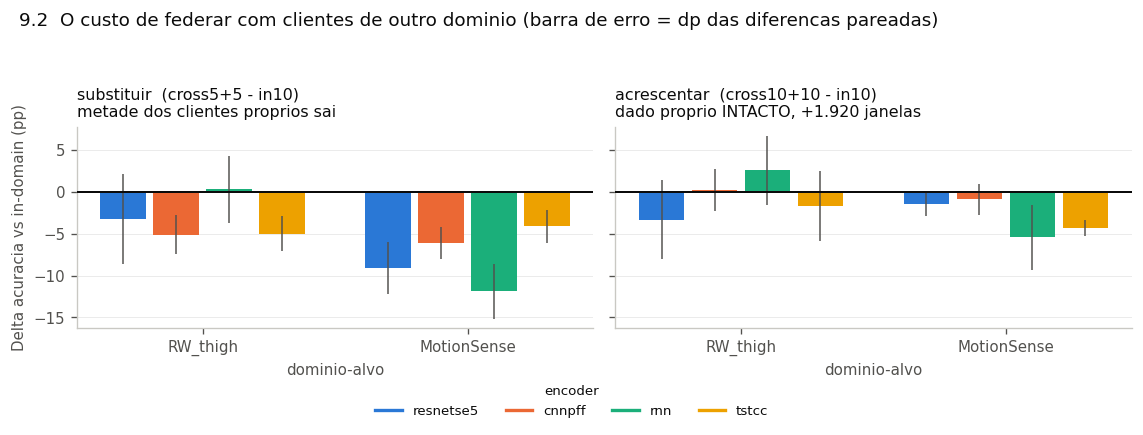

Δ em pp, pareado por seed (negativo = a federacao piorou):


alvo                   RealWorld_thigh  MotionSense
contraste   encoder                                
substituir  resnetse5             -3.2         -9.1
            cnnpff                -5.1         -6.1
            rnn                    0.3        -11.9
            tstcc                 -5.0         -4.1
acrescentar resnetse5             -3.3         -1.4
            cnnpff                 0.2         -0.9
            rnn                    2.6         -5.4
            tstcc                 -1.7         -4.3


Quantas das 8 celulas (4 encoders x 2 alvos) sao negativas:


,celulas,negativas,media
contraste,,,
acrescentar,8,6,-1.8
substituir,8,7,-5.5


In [30]:
def plot_contrastes(ct):
    if ct.empty:
        print('sem contraste calculavel ainda.')
        return
    fig, axes = plt.subplots(1, 2, figsize=(9.6, 3.5), sharey=True)
    x, w = np.arange(len(TGT)), 0.8 / len(ENCODERS)
    for ax, rot in zip(axes, CONTRASTES):
        s = ct[ct.contraste == rot]
        for j, enc in enumerate(ENCODERS):
            k = s[s.encoder == enc].set_index('alvo').reindex(TGT)
            ax.bar(x + (j - (len(ENCODERS) - 1) / 2) * w, k.delta, w * 0.86,
                   color=COLOR[enc], label=enc, yerr=k.dp,
                   error_kw=dict(ecolor=INK_2, lw=0.9, capsize=0), zorder=3)
        ax.axhline(0, color=INK, lw=1.2, zorder=4)
        ax.set_xticks(x)
        ax.set_xticklabels([CURTO[t] for t in TGT])
        ax.grid(axis='x', alpha=0)
    axes[0].set_title('substituir  (cross5+5 - in10)\nmetade dos clientes proprios sai',
                      fontsize=9.5, loc='left', color=INK)
    axes[1].set_title('acrescentar  (cross10+10 - in10)\ndado proprio INTACTO, +1.920 janelas',
                      fontsize=9.5, loc='left', color=INK)
    axes[0].set_ylabel('Delta acuracia vs in-domain (pp)')
    for ax in axes:
        ax.set_xlabel('dominio-alvo')
    fig.suptitle('9.2  O custo de federar com clientes de outro dominio '
                 '(barra de erro = dp das diferencas pareadas)',
                 fontsize=11, x=0.02, ha='left', color=INK)
    series_legend(fig, COLOR, ENCODERS, 'encoder')
    fig.tight_layout(rect=[0, 0.07, 1, 0.92])
    plt.show()


plot_contrastes(ct)

print('Δ em pp, pareado por seed (negativo = a federacao piorou):')
display(ct.pivot_table(index=['contraste', 'encoder'], columns='alvo',
                       values='delta')
        .reindex([(c, e) for c in CONTRASTES for e in ENCODERS])[TGT].round(1))

neg = ct.groupby('contraste')['delta'].agg(
    celulas='size', negativas=lambda s: int((s < 0).sum()), media='mean')
print('\nQuantas das 8 celulas (4 encoders x 2 alvos) sao negativas:')
display(neg.round(1))

### 9.3 Dose e resposta — o custo cresce onde há mais shift?

Mostrar que a federação piora é metade do argumento. A outra metade é mostrar que ela
piora **na medida do shift**: se a queda for maior justamente nos pares de domínio mais
distantes, a atribuição ao domínio deixa de ser inferência e passa a ser padrão.

Isso exige medir a distância entre domínios **sem usar estes runs**. A medida vem da
matriz de transfer supervisionada centralizada (`supervised_eval_transfer.csv`):

```
gap(encoder, alvo) = acc(treino no proprio dominio -> alvo)
                   - acc(treino no OUTRO dominio  -> alvo)
```

> **Por que isto não é o artefato de sempre.** Correlacionar o Δ federado contra o
> custo de shift medido *no próprio baseline federado* poria o mesmo termo nos dois
> eixos, e ruído puro já geraria correlação — foi assim que uma análise anterior deste
> projeto produziu um r = −0,70 que não significava nada. Aqui o `gap` vem de execuções
> **centralizadas**, que não compartilham nenhum run com esta grade. Os dois eixos são
> independentes.

Com **n = 8** (4 encoders × 2 alvos) o intervalo de confiança de qualquer r é
larguíssimo. O número serve para descrever o padrão da figura, não para testá-lo.

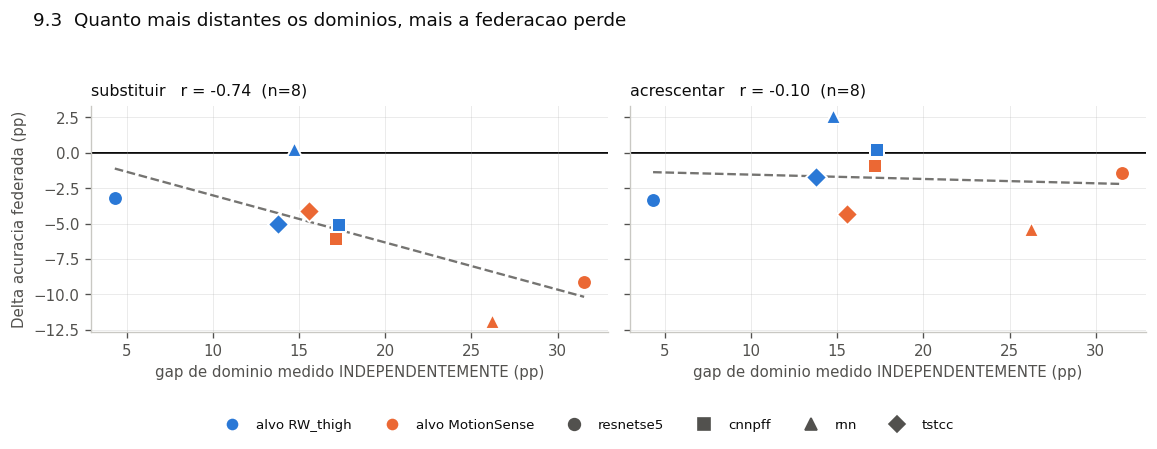

Gap independente e Delta federado, por celula (pp):


acrescentar  substituir   gap
alvo            encoder                                 
MotionSense     cnnpff            -0.9        -6.1  17.2
                resnetse5         -1.4        -9.1  31.5
                rnn               -5.4       -11.9  26.2
                tstcc             -4.3        -4.1  15.6
RealWorld_thigh cnnpff             0.2        -5.1  17.3
                resnetse5         -3.3        -3.2   4.3
                rnn                2.6         0.3  14.7
                tstcc             -1.7        -5.0  13.8


Media por alvo — o alvo com MAIS shift e o que mais perde:


gap  delta
alvo            contraste               
MotionSense     acrescentar  22.6   -3.0
                substituir   22.6   -7.8
RealWorld_thigh acrescentar  12.5   -0.6
                substituir   12.5   -3.2

In [31]:
SL_TRANSFER = PROJECT_ROOT / 'results' / 'supervised_eval_transfer.csv'

# Cor por ALVO (2 slots) e forma por encoder. A paleta de 4 cores do notebook valida
# na lista de pares ADJACENTES, que e a que vale para barras; num scatter a lista
# relevante e a de TODOS os pares, e ali o laranja e o ambar caem a dE 13.7 — abaixo
# do piso de 15 da visao normal. Com 2 cores (dE 33.6) e forma carregando o encoder,
# passa limpo.
CT_ALVO = {'RealWorld_thigh': '#2a78d6', 'MotionSense': '#eb6834'}
MARCA = {'resnetse5': 'o', 'cnnpff': 's', 'rnn': '^', 'tstcc': 'D'}


def gap_independente():
    """Distancia entre dominios medida em runs CENTRALIZADOS — eixo independente."""
    t = pd.read_csv(SL_TRANSFER)
    t = t[t.n_shots.astype(str) == 'full']
    m = (t[t.source.isin(TGT) & t.target.isin(TGT)]
         .groupby(['encoder', 'source', 'target'])['test_acc'].mean() * 100)
    rows = []
    for tgt in TGT:
        outro = [d for d in TGT if d != tgt][0]
        for enc in ENCODERS:
            rows.append({'encoder': enc, 'alvo': tgt,
                         'gap': m.loc[(enc, tgt, tgt)] - m.loc[(enc, outro, tgt)]})
    return pd.DataFrame(rows)


dose = ct.merge(gap_independente(), on=['encoder', 'alvo'])


def plot_dose(dose):
    if dose.empty:
        print('sem dados para a dose-resposta.')
        return
    fig, axes = plt.subplots(1, 2, figsize=(9.6, 3.6), sharex=True, sharey=True)
    for ax, rot in zip(axes, CONTRASTES):
        s = dose[dose.contraste == rot]
        for _, r in s.iterrows():
            ax.scatter(r.gap, r.delta, s=80, color=CT_ALVO[r.alvo],
                       marker=MARCA[r.encoder], ec='white', lw=1.2, zorder=3)
        rr = np.corrcoef(s.gap, s.delta)[0, 1]
        xs = np.linspace(dose.gap.min(), dose.gap.max(), 10)
        ax.plot(xs, np.polyval(np.polyfit(s.gap, s.delta, 1), xs), color=INK_2,
                lw=1.4, ls='--', alpha=0.8, zorder=2)
        ax.axhline(0, color=INK, lw=1.2, zorder=1)
        ax.set_title(f'{rot}   r = {rr:+.2f}  (n={len(s)})', fontsize=9.5,
                     loc='left', color=INK)
        ax.set_xlabel('gap de dominio medido INDEPENDENTEMENTE (pp)')
    axes[0].set_ylabel('Delta acuracia federada (pp)')
    fig.suptitle('9.3  Quanto mais distantes os dominios, mais a federacao perde',
                 fontsize=11, x=0.02, ha='left', color=INK)
    fig.legend(handles=[Line2D([0], [0], marker='o', ls='', color=c, ms=8,
                               mec='white', label=f'alvo {CURTO[t]}')
                        for t, c in CT_ALVO.items()]
               + [Line2D([0], [0], marker=MARCA[e], ls='', color=INK_2, ms=7,
                         label=e) for e in ENCODERS],
               loc='lower center', ncol=6, fontsize=8, bbox_to_anchor=(0.5, -0.02))
    fig.tight_layout(rect=[0, 0.09, 1, 0.93])
    plt.show()


plot_dose(dose)

print('Gap independente e Delta federado, por celula (pp):')
display(dose.pivot_table(index=['alvo', 'encoder'], columns='contraste',
                         values='delta').join(
    dose.groupby(['alvo', 'encoder'])['gap'].first()).round(1))

print('\nMedia por alvo — o alvo com MAIS shift e o que mais perde:')
display(dose.groupby(['alvo', 'contraste']).agg(
    gap=('gap', 'mean'), delta=('delta', 'mean')).round(1))

### 9.4 O controle — é o domínio, ou é federar que já custa?

Uma objeção óbvia: *"talvez qualquer heterogeneidade entre clientes prejudique o
FedAvg, e domínio não tenha nada de especial"*. O braço `iid` responde. Ele usa **as
mesmas janelas do mesmo dataset**, mesma quantidade de clientes, mesmas classes — só
quebra a fronteira entre pessoas em fatias aleatórias. O Δ `device − iid` é, então, o
custo de o cliente ser **uma pessoa** em vez de uma amostra aleatória: feature skew
puro, sem nenhum domínio envolvido.

Comparar os dois na mesma escala é o que separa "domain shift importa" de
"heterogeneidade importa".

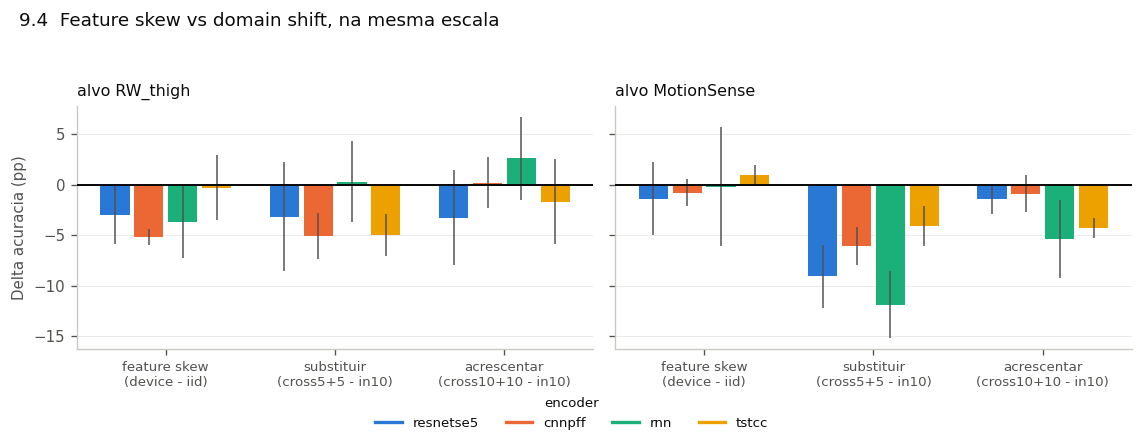

Media por eixo e alvo (pp) — quanto cada tipo de heterogeneidade custa:


alvo,RealWorld_thigh,MotionSense
eixo,,
feature skew\n(device - iid),-3.0,-0.4
substituir\n(cross5+5 - in10),-3.2,-7.8
acrescentar\n(cross10+10 - in10),-0.6,-3.0


In [32]:
IID_ARM = {'RealWorld_thigh': 'iid-RW', 'MotionSense': 'iid-MS'}
EIXOS = ['feature skew\n(device - iid)', 'substituir\n(cross5+5 - in10)',
         'acrescentar\n(cross10+10 - in10)']


def tidy_eixos(ab):
    """Os tres Δ na MESMA escala — feature skew e os dois contrastes de dominio."""
    f = delta_frame(ab, [(IN_ARM[t], IID_ARM[t], t) for t in TGT])
    fs = f[['encoder', 'alvo', 'delta', 'dp']].assign(eixo=EIXOS[0])
    fs[['delta', 'dp']] *= 100
    dom = ct.assign(eixo=ct.contraste.map(dict(zip(CONTRASTES, EIXOS[1:]))))
    return pd.concat([fs, dom[['encoder', 'alvo', 'delta', 'dp', 'eixo']]],
                     ignore_index=True)


eixos = tidy_eixos(best)


def plot_eixos(e):
    fig, axes = plt.subplots(1, 2, figsize=(9.6, 3.6), sharey=True)
    x, w = np.arange(len(EIXOS)), 0.8 / len(ENCODERS)
    for ax, tgt in zip(axes, TGT):
        s = e[e.alvo == tgt]
        for j, enc in enumerate(ENCODERS):
            k = s[s.encoder == enc].set_index('eixo').reindex(EIXOS)
            ax.bar(x + (j - (len(ENCODERS) - 1) / 2) * w, k.delta, w * 0.86,
                   color=COLOR[enc], label=enc, yerr=k.dp,
                   error_kw=dict(ecolor=INK_2, lw=0.9, capsize=0), zorder=3)
        ax.axhline(0, color=INK, lw=1.2, zorder=4)
        ax.set_xticks(x)
        ax.set_xticklabels(EIXOS, fontsize=8)
        ax.set_title(f'alvo {CURTO[tgt]}', fontsize=9.5, loc='left', color=INK)
        ax.grid(axis='x', alpha=0)
    axes[0].set_ylabel('Delta acuracia (pp)')
    fig.suptitle('9.4  Feature skew vs domain shift, na mesma escala',
                 fontsize=11, x=0.02, ha='left', color=INK)
    series_legend(fig, COLOR, ENCODERS, 'encoder')
    fig.tight_layout(rect=[0, 0.07, 1, 0.93])
    plt.show()


plot_eixos(eixos)

print('Media por eixo e alvo (pp) — quanto cada tipo de heterogeneidade custa:')
display(eixos.pivot_table(index='eixo', columns='alvo', values='delta')
        .reindex(EIXOS)[TGT].round(1))

### 9.5 Veredito

**A hipótese se sustenta nesta base, com uma qualificação que vale registrar.**

**Intercambiabilidade: refutada com folga.** Em `cross5+5 − in10`, **7 das 8 células**
são negativas, média **−5,5 pp**. Trocar metade dos clientes por gente de outro dataset
custa, mantidos constantes o número de clientes e o orçamento total. E a queda é
**proporcional à distância entre os domínios** medida independentemente (r = −0,74,
n=8): duas evidências de fontes distintas apontando na mesma direção.

**Transferência negativa: confirmada, e mais modesta.** Em `cross10+10 − in10`, **6 das
8 células** ainda pioram, média **−1,8 pp** — com o dado próprio intacto e 1.920 janelas
rotuladas a mais. São rótulos que deixaram o modelo **pior**. Mas ~2 pp, não 10: o
número de vitrine (−11,9 pp do `rnn` no `cross5+5`) mede a não-intercambiabilidade, que
é uma afirmação mais fraca, e não deve ser citado como "o custo do domain shift".

**O custo é assimétrico, e essa é a leitura mais interessante.** Quem paga é o domínio
com mais shift:

| alvo | gap independente | cross5+5 | cross10+10 |
|---|---|---|---|
| MotionSense | 22,6 pp | −7,8 | **−3,0** |
| RealWorld_thigh | 12,5 pp | −3,2 | **−0,6** |

Acrescentar clientes de RealWorld a uma federação MotionSense **atrapalha**. O
contrário é quase de graça. Um desenho federado que trate a mistura como simétrica
está errado sobre este par.

**O que NÃO se sustenta:** que domain shift seja a heterogeneidade dominante. No alvo
RealWorld_thigh o **feature skew** custa −3,0 pp — **cinco vezes** o custo de
acrescentar um domínio estrangeiro (−0,6). Ali, quem prejudica a federação é o cliente
ser uma pessoa, não ser de outro dataset. A afirmação defensável é *"domain shift
prejudica federações supervisionadas, e prejudica mais onde os domínios estão mais
distantes"* — não *"domain shift é o principal problema do FedAvg"*.

**Limites deste teste.**

1. **Um par de domínios.** RW_thigh ↔ MotionSense, ambos do grupo perna — o par de
   menor distância esperada do DAGHAR. Cintura↔perna daria gaps maiores. Um par não
   estabelece uma curva dose-resposta; estabelece dois pontos dela.
2. **n = 8 para o r.** Com 8 pontos o intervalo de confiança cobre quase tudo. O
   r = −0,74 descreve a figura; não a testa.
3. **O `cross10+10` tem 20 clientes contra 10 do `in10`.** O dado próprio está intacto,
   que é o que o teste de transferência negativa exige, mas o número de participantes
   dobra — e o FedAvg tem dinâmica própria com mais clientes.
4. **Só o degrau `full`.** O custo do shift muda com o orçamento de rótulos, e muda
   numa direção que surpreende — ver `cross_device_fewshot_avaliation.ipynb` §9.
5. **Só supervisionado.** Este é o contrafactual medido sozinho; se o Fed-SSL mitiga o
   que foi medido aqui é pergunta de outro notebook.
